# TP 3 · Retour sur le Titanic — Utilisation d'une méthode ensembliste

**Jour 2 — chapitre 04 : Data visualisation & méthodes ensemblistes**

## Mise en situation

En reprenant le modèle de régression logistique construit précédemment, il s'agit de
comparer sa performance à celle d'une méthode ensembliste, sur les mêmes features.


In [1]:
import pandas as pd
import seaborn as sns

titanic_raw = sns.load_dataset("titanic")
titanic = titanic_raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
})[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

# Nettoyage (TP "valeurs manquantes", notebook 03)
age_median_par_groupe = titanic.groupby(["Sex", "Pclass"])["Age"].transform("median")
titanic["Age"] = titanic["Age"].fillna(age_median_par_groupe).fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# Feature engineering (TP "feature engineering", notebook 04)
titanic = pd.get_dummies(titanic, columns=["Sex", "Embarked"], drop_first=True)
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

# PassengerId synthetique pour le format de soumission (le dataset seaborn n'en fournit pas)
titanic = titanic.reset_index(drop=True)
titanic.insert(0, "PassengerId", titanic.index + 1)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_male"]
features = [c for c in features if c in titanic.columns]

X = titanic[features]
y = titanic["Survived"]

titanic.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,1,0,3,22.0,1,0,7.2500,True,False,True,2,0
1,2,1,1,38.0,1,0,71.2833,False,False,False,2,0
2,3,1,3,26.0,0,0,7.9250,False,False,True,1,1
3,4,1,1,35.0,1,0,53.1000,False,False,True,2,0
4,5,0,3,35.0,0,0,8.0500,True,False,True,1,1


## Étape 1 — Entraîner un RandomForestClassifier sur les mêmes features

**Question de réflexion :** un Random Forest a-t-il besoin d'un encodage particulier ou
d'une normalisation, comme la régression logistique ?


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Suivi des expériences avec MLflow

On réutilise ici la même expérience MLflow que dans le notebook précédent (`OFDS - Jour 2 - Titanic`) : les runs de ce TP viendront s'ajouter à ceux de la régression logistique déjà enregistrés, pour une comparaison directe dans la même vue.

Plutôt que de garder une trace manuelle des scores dans un carnet ou un tableur (voir la
check-list du jour 3 : « a-t-on conservé une trace des expériences menées ? »), on utilise
ici **MLflow** pour enregistrer automatiquement les paramètres et les métriques de chaque
essai.

Ceci suppose qu'un serveur de tracking MLflow tourne en local, lancé au préalable avec :

```bash
mlflow server --host 127.0.0.1 --port 5001 \
    --backend-store-uri sqlite:///mlflow_data/mlflow.db \
    --default-artifact-root ./mlflow_data/mlartifacts
```

L'interface est ensuite consultable dans un navigateur à l'adresse
http://127.0.0.1:5001. Voir `demos/README.md` pour le détail, et
`speech/ressources-techniques.md` pour son rôle dans la stack technique.

Si aucun serveur n'est joignable (par exemple sur Kaggle Notebooks ou Colab, qui ne
voient pas votre machine locale), remplacez la ligne `mlflow.set_tracking_uri(...)`
ci-dessous par `mlflow.set_tracking_uri("file:./mlruns")` : MLflow écrit alors ses runs
dans un simple dossier local, consultable plus tard avec `mlflow ui`.


In [3]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5001")
experience = mlflow.set_experiment("OFDS - Jour 2 - Titanic")
print("Expérience MLflow active :", experience.name)


Expérience MLflow active : OFDS - Jour 2 - Titanic


In [4]:
logreg = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)

with mlflow.start_run(run_name="logreg_vs_rf_logreg"):
    scores_logreg = cross_val_score(logreg, X_train, y_train, cv=5)
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("cv_accuracy_mean", scores_logreg.mean())

with mlflow.start_run(run_name="random_forest"):
    scores_rf = cross_val_score(rf, X_train, y_train, cv=5)
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("cv_accuracy_mean", scores_rf.mean())

print("Régression logistique — score moyen CV :", round(scores_logreg.mean(), 3))
print("Random Forest — score moyen CV :", round(scores_rf.mean(), 3))


View run logreg_vs_rf_logreg at: http://127.0.0.1:5001/#/experiments/1/runs/4c8255039a5b46c8bd2365120d157b7f
View experiment at: http://127.0.0.1:5001/#/experiments/1


View run random_forest at: http://127.0.0.1:5001/#/experiments/1/runs/af7d0d7b78914c51a152e9ea0314c9e5
View experiment at: http://127.0.0.1:5001/#/experiments/1
Régression logistique — score moyen CV : 0.803
Random Forest — score moyen CV : 0.827


**Ce qu'on observe** : contrairement au k-NN ou à la régression, un Random Forest n'a pas
besoin de standardisation des variables continues — les arbres de décision sont
insensibles à l'échelle des variables (point vu en cours dans le chapitre « Data
cleaning »). Les deux runs MLflow (`logreg_vs_rf_logreg` et `random_forest`) permettent de
retrouver ces deux scores sans avoir à les recopier ailleurs.


## Étape 2 — Comparer le score en cross-validation avec celui de la régression logistique

**Question de réflexion :** si le Random Forest fait mieux, est-ce forcément parce que
c'est un « meilleur » algorithme dans l'absolu, ou est-ce lié à ce dataset précis ?


**Réponse commentée**

Les deux scores ci-dessus permettent une comparaison équitable, car ils sont calculés sur
les mêmes plis de cross-validation. Un Random Forest capture mieux les interactions non
linéaires entre variables (par exemple, l'effet de l'âge peut être différent selon le
sexe et la classe), ce qui explique souvent un gain sur ce type de données tabulaires,
sans que ce soit une règle universelle valable sur tout dataset.


## Étape 3 — Afficher l'importance des features

**Question de réflexion :** quelles variables pèsent le plus dans les prédictions du
modèle ? Est-ce cohérent avec les hypothèses métier posées en jour 1 (sexe, classe) ?


In [5]:
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances


Sex_male      0.454903
Fare          0.177845
Pclass        0.136471
Age           0.132787
FamilySize    0.081974
IsAlone       0.016020
dtype: float64

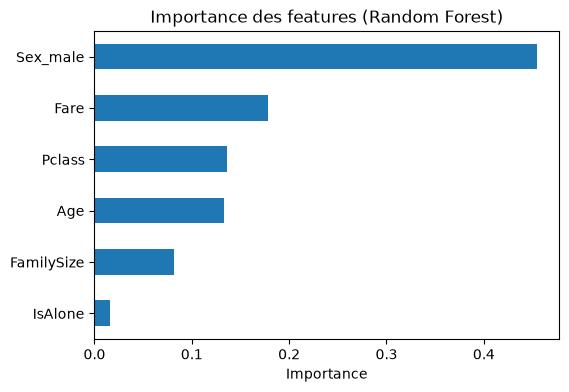

In [6]:
import matplotlib.pyplot as plt

fig_importance, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax)
ax.set_title("Importance des features (Random Forest)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.show()


**Ce qu'on observe** : `Sex_male` et `Fare` (souvent corrélé à la classe) arrivent
généralement en tête, ce qui confirme les hypothèses formulées en jour 1 lors de la toute
première exploration des données.


## Étape 4 — Générer une nouvelle soumission Kaggle

**Question de réflexion :** le format de soumission change-t-il selon l'algorithme
utilisé ?


In [7]:
from sklearn.metrics import accuracy_score

with mlflow.start_run(run_name="random_forest_final"):
    rf.fit(X_train, y_train)
    predictions_rf = rf.predict(X_test)
    test_accuracy_rf = accuracy_score(y_test, predictions_rf)

    submission_rf = pd.DataFrame({
        "PassengerId": titanic.loc[X_test.index, "PassengerId"],
        "Survived": predictions_rf,
    })
    submission_rf.to_csv("submission_random_forest.csv", index=False)

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("test_accuracy", test_accuracy_rf)
    # MLflow enregistre les modeles scikit-learn au format skops, qui refuse par securite les
    # arbres (sklearn.tree._tree.Tree) tant qu'on ne les declare pas comme surs. Le modele vient
    # d'etre entraine ici meme : on peut lui faire confiance.
    mlflow.sklearn.log_model(rf, name="model", skops_trusted_types=["sklearn.tree._tree.Tree"])
    mlflow.log_figure(fig_importance, "feature_importance.png")
    mlflow.log_artifact("submission_random_forest.csv")

print("Accuracy Random Forest sur notre jeu de test local :", round(test_accuracy_rf, 3))
submission_rf.head()


View run random_forest_final at: http://127.0.0.1:5001/#/experiments/1/runs/2ad5e48240c8492f80bfd164075a897d
View experiment at: http://127.0.0.1:5001/#/experiments/1
Accuracy Random Forest sur notre jeu de test local : 0.81


,PassengerId,Survived
709,710,0
439,440,0
840,841,0
720,721,1
39,40,1


**Ce qu'on observe** : le format de soumission (`PassengerId`, `Survived`) ne dépend pas
de l'algorithme utilisé — seule la façon d'obtenir les prédictions change. C'est
précisément l'intérêt du pattern scikit-learn `.fit()` / `.predict()`, commun à tous les
modèles. Le graphique d'importance des features est lui aussi attaché au run MLflow
(`feature_importance.png`), au même titre que le fichier de soumission.

**À retenir pour le débriefing du TP** : ouvrez http://127.0.0.1:5001, expérience
« OFDS - Jour 2 - Titanic » : vous devriez maintenant voir, dans une même liste, les runs
du notebook précédent (régression logistique, avec et sans GridSearchCV) et ceux de ce
TP (régression logistique, Random Forest). Comparez les colonnes de métriques pour
discuter avec le groupe quelle configuration retenir comme meilleure baseline pour la
suite.
